In [1]:
# Step 1: Install Required Libraries
!pip install -q tensorflow tensorflow_hub matplotlib

# Step 2: Import Dependencies
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import requests
from io import BytesIO


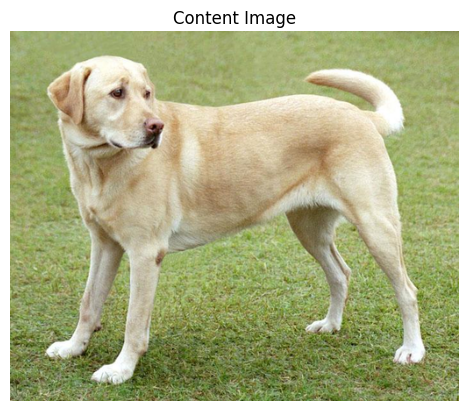

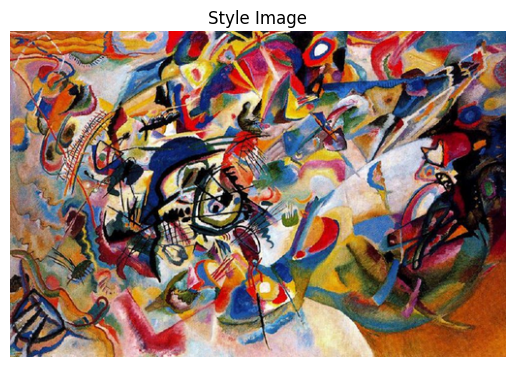

In [4]:
def load_image_from_url(url, max_dim=512):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content))
    image = image.convert("RGB")

    # Resize
    scale = max_dim / max(image.size)
    size = tuple([int(d * scale) for d in image.size])
    image = image.resize(size, Image.Resampling.LANCZOS)

    img = np.array(image)
    img = img.astype(np.float32)[np.newaxis, ...] / 255.0
    return img

# Example content and style images
content_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg'
style_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg'


content_image = load_image_from_url(content_url)
style_image = load_image_from_url(style_url)

# Show input images
def imshow(image, title=None):
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

imshow(content_image, 'Content Image')
imshow(style_image, 'Style Image')


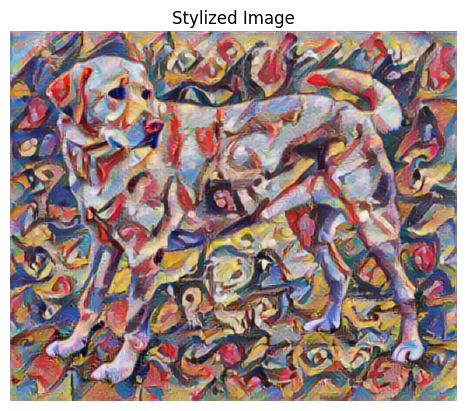

In [5]:
# Load the model
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

# Stylize the image
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]

# Show result
imshow(stylized_image, 'Stylized Image')
